# Streaming Data
    - Getting results from the graph while its still running.
        - messages as they are generated
        - node outputs as they happen
        - state updates as it happens
  - This makes your app feel fast, responsive, and alive — especially when LLMs take time to respond.
### Advantage:
    - Human in the loop system allows users to interact directly with graphs in various ways.
    - faster and responsive agent 
    - helps trace and debug errors easily

## Goals: 
    - Module with Human-in-the-loop and long-term memory that allows user to interact with and debug the graph.
    - stream state and llm tokens over the course of interaction

In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"
                                         

In [2]:
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'

In [3]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [8]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemma-3-4b-it" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

'Today is Wednesday, November 8, 2023. 😊 \n\nDo you want to know anything else about the date?'

# Streaming - full state

## Types 
    1. sync : .stream - delivers chuncks as its available
    2. async : .astream - uses async / await , occurs concurrently, helps run multiple tasks at the same time  and integrats with async web servers (FastAPI, etc.)

## Streaming Modes :

- values: This streams the full state of the graph after each node is called.
- updates: This streams updates to the state of the graph after each node is called. We only see updates to the state after node in the graph is run.
- messages: This streams chat messages as they are produced.
- custom: This is a user‑defined streaming channel.  You only get "custom" events if you create them yourself inside your graph.

EX: stream_mode ="updates" : Each chunk is a dict with node_name as the key and the updated state as the value.

### Build a long term external DB agent that summerizes the conversation history.

In [19]:
#import os
os.makedirs("state_db", exist_ok=True)


In [13]:
# Create a external db
import sqlite3
db_path = "state_db/StreamingAgent.db"
conn = sqlite3.connect(db_path , check_same_thread=False)

# confirm the file was create4d:
os.listdir("state_db")


['StreamingAgent.db',
 'StreamingAgent.db-shm',
 'StreamingAgent.db-wal',
 'token_streaming.db',
 'token_streaming.db-shm',
 'token_streaming.db-wal']

In [14]:
# create a checkpointer SqLiteSaver
from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver(conn)

## RunnableConfig : from langchain_core.runnables import RunnableConfig
 -  use RunnableConfig in llm_chatbot function as a parameter to enable token-wise streaming.
 -  This is only needed with python < 3.11.
 -  include in case you are running this notebook in CoLab, which will use python 3.x.
 -  EX: def call_model(state: State, config: RunnableConfig):
 - 

In [26]:
import sys
print(sys.version) # since we use version > 3.1 ,  we cna skip RunnableConfig

3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]


### Re-build summary chatbot

In [15]:
from langgraph.graph import MessagesState , StateGraph , START , END
from langchain_core.messages import HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig

# create state
class summary_state(MessagesState):
    summary: str

# define nodes
def llm_chatbot(state:summary_state):
    # check if summary exists
    summary = state.get('summary' , "")
    if summary:
        msg = [HumanMessage(content=f"This is the summary of past conversations:{summary}")]
        messages = msg + state['messages']
    else:
        messages = state['messages']
    response = llm.invoke(messages)
    return {'messages' : [response] }

# defining summerize node
def summarize(state:summary_state):
    # check if summary exists
    summary = state.get('summary' , "")
    if summary:
        instr = f"This is the summary of past conversation history :\n {summary}\n\n. Add the current conversation messages above to the past summary to create a new summary. Keep the fact, interests and all the important information intact. do not assume."
        
    else:
        instr = "Summarize the above conversation so far. Ensure all the facts , interests and important informations are preserved."

    msg = [HumanMessage(content=instr)]
    messages = state['messages' ] + msg
    # summarise
    summary = llm.invoke(messages)
    print("Summary generated: " , summary.content[0]['text'])
    # delete old messages while saving just 2 conversation
    deleted_msgs = [RemoveMessage(id = m.id) for m in state['messages'][:-2]]
    return {'messages' : deleted_msgs, 'summary': summary.content[0]['text'] }

# decision  function
from typing import Literal

def decide(state:summary_state)->Literal['summarize' , END] :
    if len(state['messages']) > 4:
        return 'summarize'
    else:
        return END


## Compile with sqliteSaver as memory


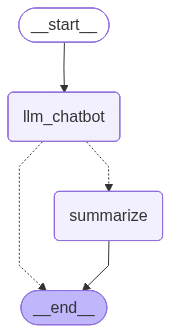

In [16]:
from IPython.display import Image, display

# initialize graph
builder = StateGraph(summary_state)

# add nodes
builder.add_node('llm_chatbot' , llm_chatbot)
builder.add_node('summarize' , summarize)

# build adges
builder.set_entry_point('llm_chatbot')
builder.add_conditional_edges('llm_chatbot', decide)
builder.add_edge('summarize', END)

# compile with sqlite db memory
graph = builder.compile(checkpointer=memory)

# display graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Invoke graph with persistant long-term memory creating a thread ID 
### Stream_mode = 'updates'
    - prints data everytime the node updates the state

In [ ]:
# create a thread
config = {"configurable":{"thread_id":"D-2"}}

In [53]:
# run 3 times-  streamingconversation:
for chunk in graph.stream({'messages':[HumanMessage(content="Tell me a 1 line ice cream joke. use different jokes everytime.")]},config , stream_mode="updates"):
    print(chunk)

{'llm_chatbot': {'messages': [AIMessage(content=[{'type': 'text', 'text': 'Why do ice cream cones always carry umbrellas? In case of sprinkles!', 'extras': {'signature': 'EqMOCqAOAQw51sfvsfxBF4oLzyfp3rOw/EcRge0hmnwqhJAgDPBw/fCFZMa/RF+Nv6BUJOsWb1eLGo9MlhvcL2eIQuA6sTSh9xVnSpPVABPXq/dR9UDDL6Xgh4VMH9Smy0sGh5sEPMGeGDlqq/MU8kh13kZjZb0pumnR41le48qW+jbORgC/9I8nYHRGXnW7+IZKVICjxnqiEhBheqdTww0aRXEaHcHWVi87SKfMQ0rLUksA9hm7bYufNngePGR2S1zrBrHYspm53vOGKKfEWuX5w6ichvSJO5OTh0cvTDxHRSB9Xgj8PzUEBA53is/iF3N0viJBgunCTQTkgEZDM03O8T23aktOBqocqRtX9w5njtqEO9VtHOXPHXJA42+LUJtFmC5KVeozsJojWbDvH2RlM9lsTlzuF+xTU7bUuL2+CpdSWO+Z/VevJulPgDkbrSe1Ubn6d+7VIbnGghzp3AhHY/DCtGTQJ00fNAK/2+xazvPMS52tAgcgBGs68nnyFpwe8PBof4X6idcQqFxehROZPuTHw/3vHGDD/vYeubT8nkyQKWLmrGVgfAhdzh96Skx0lkMfP92h50dghhEpreTDmxwdpVZd7Iw241sXofRXpqoRGOdj8x/g7fDsD5ierFniM9N2Jtery8nnV5Kbi5iMe0fCKz8aAzE4Axl4SqjwEQoU4HLRa6JkGydgxfTMcYuv8Yall9uLuA7ykq1aYo3vptJJ+DTT8ohsI9AwxNGZ6DACuKo7avLnCaNlPUGC6e5BhNXk9cSu4In1d4ry/UvEcKcG4exDYHC/FOL4Awrc8ZfJvrt2ziwYCTNEQ

In [48]:
for chunk in result:
    print(chunk)

### extract the 'summary' from the state

In [57]:
state_updated = graph.get_state(config).values.get('summary',"")
state_updated

'The user has requested a series of unique, one-line ice cream jokes. So far, three jokes have been provided: one about "Sundae" being a favorite day, one regarding a truck breakdown on a "rocky road," and one about cones carrying umbrellas for "sprinkles." The primary interest is receiving short, ice-cream-themed humor while ensuring no jokes are repeated.'

### 2. Stream_mode = "values"

### Values - this prints everytime the state values get updated 

In [64]:
# create a new thread for values
config_2 = {"configurable":{"thread_id": "2"}}

In [65]:
# streaming conversation:
for chunk in graph.stream({'messages':[HumanMessage(content="Tell me a 1 elephant joke. use different jokes everytime.")]},config_2 , stream_mode="values"):
    result = chunk
    print(chunk)


{'messages': [HumanMessage(content='Tell me a 1 elephant joke. use different jokes everytime.', additional_kwargs={}, response_metadata={}, id='6178b18b-014b-4794-bcee-a34f38e8e5e2')]}
{'messages': [HumanMessage(content='Tell me a 1 elephant joke. use different jokes everytime.', additional_kwargs={}, response_metadata={}, id='6178b18b-014b-4794-bcee-a34f38e8e5e2'), AIMessage(content=[{'type': 'text', 'text': 'Why do elephants wear sneakers?\n\nTo sneak up on people!', 'extras': {'signature': 'Eo0JCooJAQw51seUcd1wj7LIdY7G/PWr5ywKKRz28cQL1MBX0Cf6LuvDBVwalOjgCVpLYgkhhhUznVPCpSNp1P4HeygHKYse1MteBBYT3qI8+opITypoFb7c1THG2wXsFjWQuHaS/pAVb5zhHy+zPlWz5MlxRpdottaw074wIDI2rd/Gv9LsRP27LwByFXGNe8JCouCNszWrOPPWH5mjWeblBviYykOLcuGEG9Yjv2W2nuI7zoULIlfObuww/lxiQ6PbY6g1FQRVR/ZPpSBoW7V6i3FnsMM7pTwBFfyiART59MQ8pG1dw7wFVwDXIJrXmCzsBkpw5t1WaCg1UG+VQMat4Lnn403+8rFO+PuI1u3hQBbS+RB8C5PZJENX8Itb32nlo9qtJygXyChDbC9FBoNYU6/5Y2BI1OHrvEB1JKRhrD2lQPK4uCfbQ8CjmE5OYH6D1vp/h/j1u4gmMZ/+pT5Wlr+uA3qmAecbGnUN5Qg+enhPamwPq

In [66]:
for m in result['messages']:
    m.pretty_print() # state has jsut human and AI messages now

================================ Human Message =================================

Tell me a 1 elephant joke. use different jokes everytime.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Why do elephants wear sneakers?\n\nTo sneak up on people!', 'extras': {'signature': 'Eo0JCooJAQw51seUcd1wj7LIdY7G/PWr5ywKKRz28cQL1MBX0Cf6LuvDBVwalOjgCVpLYgkhhhUznVPCpSNp1P4HeygHKYse1MteBBYT3qI8+opITypoFb7c1THG2wXsFjWQuHaS/pAVb5zhHy+zPlWz5MlxRpdottaw074wIDI2rd/Gv9LsRP27LwByFXGNe8JCouCNszWrOPPWH5mjWeblBviYykOLcuGEG9Yjv2W2nuI7zoULIlfObuww/lxiQ6PbY6g1FQRVR/ZPpSBoW7V6i3FnsMM7pTwBFfyiART59MQ8pG1dw7wFVwDXIJrXmCzsBkpw5t1WaCg1UG+VQMat4Lnn403+8rFO+PuI1u3hQBbS+RB8C5PZJENX8Itb32nlo9qtJygXyChDbC9FBoNYU6/5Y2BI1OHrvEB1JKRhrD2lQPK4uCfbQ8CjmE5OYH6D1vp/h/j1u4gmMZ/+pT5Wlr+uA3qmAecbGnUN5Qg+enhPamwPqEO5VhKoZWQv32Gf28HKZ+l1vwLSE0Kss3QmKjWSod8j7yMPUfcwvd2ERqJ0ITJ74gfToxIUkYKrfJTE/biPoMWTmi913TiZYoInne9MRhg6zk0ocUfoHKl0+pKMDxShosoAvlEuxMCoMvXSDnuRjY28yYSib2qORpcqyp

In [67]:

# streaming conversation:
for chunk in graph.stream({'messages':[HumanMessage(content="Tell me a 1 ant joke.")]},config_2 , stream_mode="values"):
    result = chunk
    for m in chunk['messages']:
        m.pretty_print()

================================ Human Message =================================

Tell me a 1 elephant joke. use different jokes everytime.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Why do elephants wear sneakers?\n\nTo sneak up on people!', 'extras': {'signature': 'Eo0JCooJAQw51seUcd1wj7LIdY7G/PWr5ywKKRz28cQL1MBX0Cf6LuvDBVwalOjgCVpLYgkhhhUznVPCpSNp1P4HeygHKYse1MteBBYT3qI8+opITypoFb7c1THG2wXsFjWQuHaS/pAVb5zhHy+zPlWz5MlxRpdottaw074wIDI2rd/Gv9LsRP27LwByFXGNe8JCouCNszWrOPPWH5mjWeblBviYykOLcuGEG9Yjv2W2nuI7zoULIlfObuww/lxiQ6PbY6g1FQRVR/ZPpSBoW7V6i3FnsMM7pTwBFfyiART59MQ8pG1dw7wFVwDXIJrXmCzsBkpw5t1WaCg1UG+VQMat4Lnn403+8rFO+PuI1u3hQBbS+RB8C5PZJENX8Itb32nlo9qtJygXyChDbC9FBoNYU6/5Y2BI1OHrvEB1JKRhrD2lQPK4uCfbQ8CjmE5OYH6D1vp/h/j1u4gmMZ/+pT5Wlr+uA3qmAecbGnUN5Qg+enhPamwPqEO5VhKoZWQv32Gf28HKZ+l1vwLSE0Kss3QmKjWSod8j7yMPUfcwvd2ERqJ0ITJ74gfToxIUkYKrfJTE/biPoMWTmi913TiZYoInne9MRhg6zk0ocUfoHKl0+pKMDxShosoAvlEuxMCoMvXSDnuRjY28yYSib2qORpcqyp

### Note: Since streaming_mode = "Values" print all the values in the state messages everytime the node updates, this leads to lantency and 

# Streaming Tokens
    - while using chat model calls, it is common to stream the tokens as they are generated.
# Chat_model tokens: A token is a small chunk of text (part of a word, a word, or punctuation)
                    - Instead of waiting for the whole answer, you receive tokens or small chunks as they are generated
                    - This makes the app feel faster and more interactive, like live typing
## .astream_events method :  Streams back events as they happen inside nodes!
                    - an async streaming method in LangGraph that lets you see every internal event happening inside your graph as it happens.
                    - Think of it like turning on “developer mode” for your graph.:
                        - Instead of only seeing: 
                            - the final output
                            - or just the messages
                        - You see everything:
                            - when a node starts                            
                            - when a node finishes                            
                            - what each node returns                            
                            - state updates                            
                            - custom events                            
                            - LLM token events (if enabled)                            
                    - It’s the most detailed streaming mode LangGraph offers.

## Why .astream_events ? :
        - debugging a graph
        - watching node execution order        
        - seeing tool calls        
        - understanding how state changes        
        - building a UI that shows node‑by‑node progress        
.astream_events() is built for that.


## Async Memory Saver : 
    The SqliteSaver does not support async methods. Consider using AsyncSqliteSaver instead.
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
Note: AsyncSqliteSaver requires the aiosqlite package to use.
Install with:
`pip install aiosqlite`

## Events to consider : 
    - Each event is a dict with a few keys: Some important keys are:

    - event: This is the type of event that is being emitted.
    - name: This is the name of event.
    - data: This is the data associated with the event.
    - metadata: Containslanggraph_node, the node emitting the event.

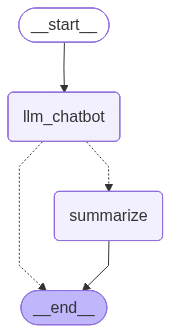

In [17]:
# set asyncSqliteSaver for async streaming with memory
import aiosqlite

conn = await aiosqlite.connect("state_db/token_streaming.db")

from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver

memory_async = AsyncSqliteSaver(conn)

# comiple with async memory

graph2 = builder.compile(checkpointer=memory_async)

graph2             

In [98]:
# set the thread ID for memory storage
config_ST = {"configurable":{"thread_id":"T4"}}
               

In [92]:
# get event , name, meatadata, data for streaming tokens from llm
async for event in graph2.astream_events({"messages":[HumanMessage(content='Tell me a 1 line joke about a cat')]},config_ST, version="v2"):
        print(f"Node: {event['metadata'].get('langgraph_node',"")}, Type: {event['event']}, Name: {event['name']}")  

Node: , Type: on_chain_start, Name: LangGraph
Node: llm_chatbot, Type: on_chain_start, Name: llm_chatbot
Node: llm_chatbot, Type: on_chat_model_start, Name: ChatGoogleGenerativeAI
Node: llm_chatbot, Type: on_chat_model_stream, Name: ChatGoogleGenerativeAI
Node: llm_chatbot, Type: on_chat_model_stream, Name: ChatGoogleGenerativeAI
Node: llm_chatbot, Type: on_chat_model_stream, Name: ChatGoogleGenerativeAI
Node: llm_chatbot, Type: on_chat_model_stream, Name: ChatGoogleGenerativeAI
Node: llm_chatbot, Type: on_chat_model_end, Name: ChatGoogleGenerativeAI
Node: llm_chatbot, Type: on_chain_start, Name: decide
Node: llm_chatbot, Type: on_chain_end, Name: decide
Node: llm_chatbot, Type: on_chain_stream, Name: llm_chatbot
Node: llm_chatbot, Type: on_chain_end, Name: llm_chatbot
Node: , Type: on_chain_stream, Name: LangGraph
Node: , Type: on_chain_end, Name: LangGraph


## Stream tokens from chatmodels
### 1. use *Type = "on_chat_model_stream"* - The event is a token from a chat mode
So if you want to stream only tokens, you filter for: if event["event"] == "on_chat_model_stream": ...

### 2. use Node = "chat_model_node_name"* - to select the node to stream from
Every event includes metadata telling you which node produced it. use if *event['metadata']['langgraph_node'] == "chat_model_node_name": ...

### Use data = AIMessageChunk - Every event has a data field that contains the payload chunk . that is the token text, the role (assistant), optional metadata. 
To print payload , use event["data"].content
- These chunks arrive one by one as the model generates them.

### EX: 
async for event in graph.astream_events(input, config, version="v2"):
    # 1. Only token events
    if event["event"] != "on_chat_model_stream":
        continue

    # 2. Only from the chatbot node
    if event["metadata"].get("langgraph_node") != "chatbot":
        continue

    # 3. Extract the token
    token = event["data"].content
    print(token, end="")

# Together, these let you:
    - stream tokens    
    - filter by node    
    - build real‑time UIs
    - debug your graph    
    - understand how LangGraph executes internally

In [19]:
# set up async streaming of tokens
config_ST = {"configurable":{"thread_id":"T8"}}
async for event in graph2.astream_events({"messages":[HumanMessage(content='Tell me a 1 line joke about a doll')]},config_ST, version="v2"):
        if event["event"] == "on_chat_model_stream" and event['metadata']['langgraph_node'] == "llm_chatbot":
            print(event['data'])

{'chunk': AIMessageChunk(content='Why', additional_kwargs={}, response_metadata={'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dccf9-36cd-7fe0-b537-dd13e83f530e', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 0, 'total_tokens': 11, 'input_token_details': {'cache_read': 0}}, tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' did', additional_kwargs={}, response_metadata={'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dccf9-36cd-7fe0-b537-dd13e83f530e', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 0, 'output_tokens': 0, 'input_token_details': {'cache_read': 0}, 'total_tokens': 0}, tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' the', additional_kwargs={}, response_metadata={'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019dccf9-36cd-7fe0-b537-dd13e83f530e', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 0, 'o

In [20]:
config_ST = {"configurable":{"thread_id":"T7"}}
input_message = HumanMessage(content="Nutritional benifit of banana in few words")
async for event in graph2.astream_events({"messages": [input_message]}, config_ST, version="v2"):
    # Get chat model tokens from a particular node 
    if event["event"] == "on_chat_model_stream" and event['metadata'].get('langgraph_node','') == 'llm_chatbot':
        data = event["data"]
        print(data["chunk"].content, end="|")

Pot|assium|-|rich|,| energy|-|boosting|,| and| good| for| digestion|!|||